In [30]:
#Analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px

#preprocessing -Model
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split #splitting
from sklearn.linear_model import LinearRegression

#Evalution (metrics)
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

In [31]:
df = pd.read_csv("house_price_regression_dataset.csv")
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [32]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [34]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [35]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
Square_Footage,0,0.0
Num_Bedrooms,0,0.0
Num_Bathrooms,0,0.0
Year_Built,0,0.0
Lot_Size,0,0.0
Garage_Size,0,0.0
Neighborhood_Quality,0,0.0
House_Price,0,0.0


C:\Users\black\AppData\Local\Temp\ipykernel_6752\2441021782.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Square_Footage'] , kde=True , palette='viridis', edgecolor='black')
D:\APLIKASI\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Square_Footage', ylabel='Count'>

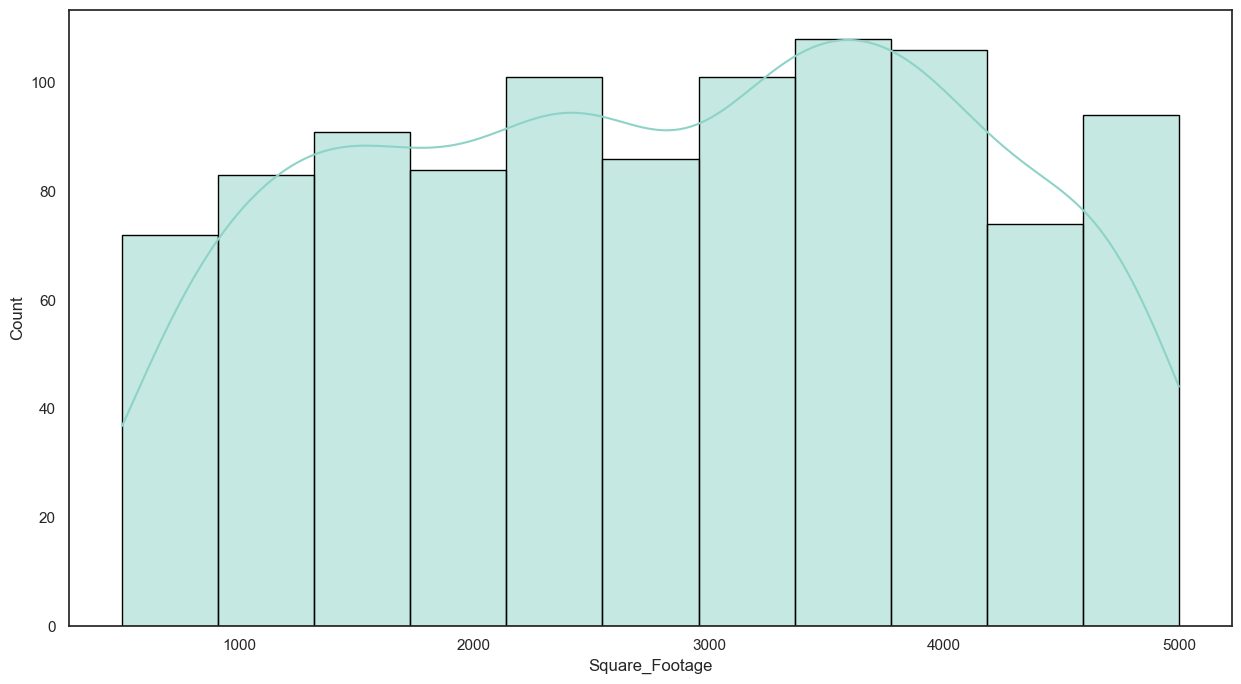

In [36]:
plt.figure(figsize=(15,8))
sns.histplot(df['Square_Footage'] , kde=True , palette='viridis', edgecolor='black')

C:\Users\black\AppData\Local\Temp\ipykernel_6752\346477915.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Num_Bedrooms'] , kde=True , palette='viridis', edgecolor='black')
D:\APLIKASI\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Num_Bedrooms', ylabel='Count'>

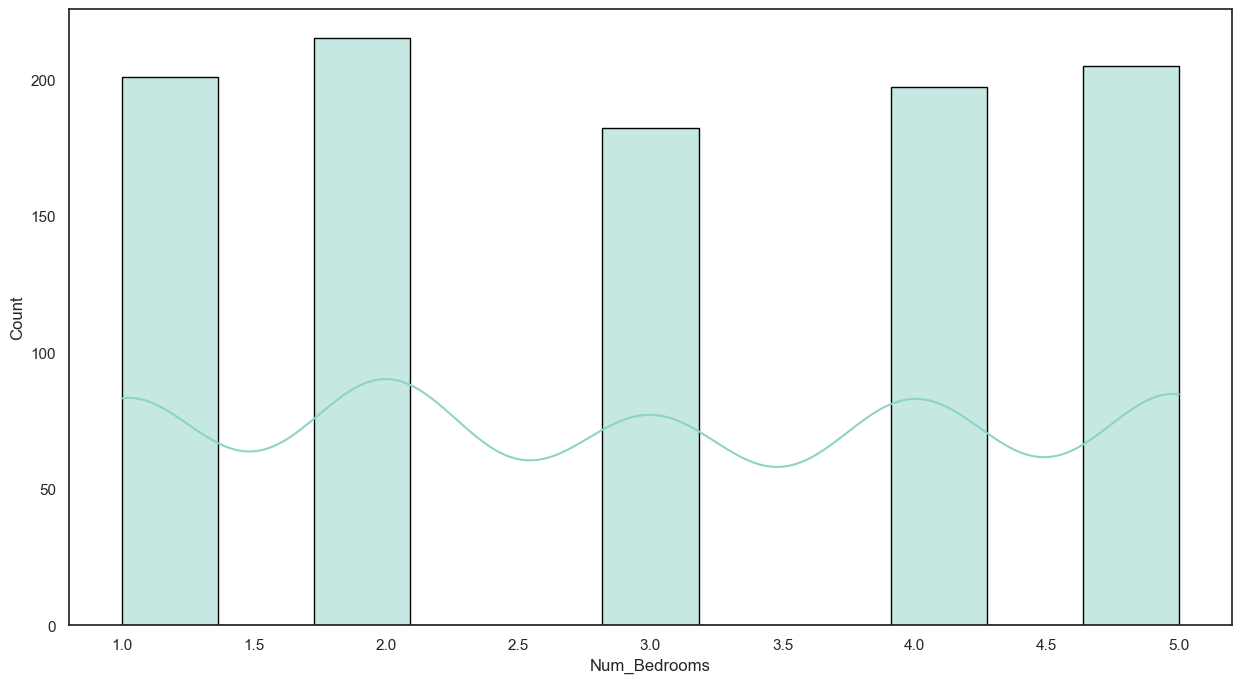

In [37]:
plt.figure(figsize=(15,8))
sns.histplot(df['Num_Bedrooms'] , kde=True , palette='viridis', edgecolor='black')

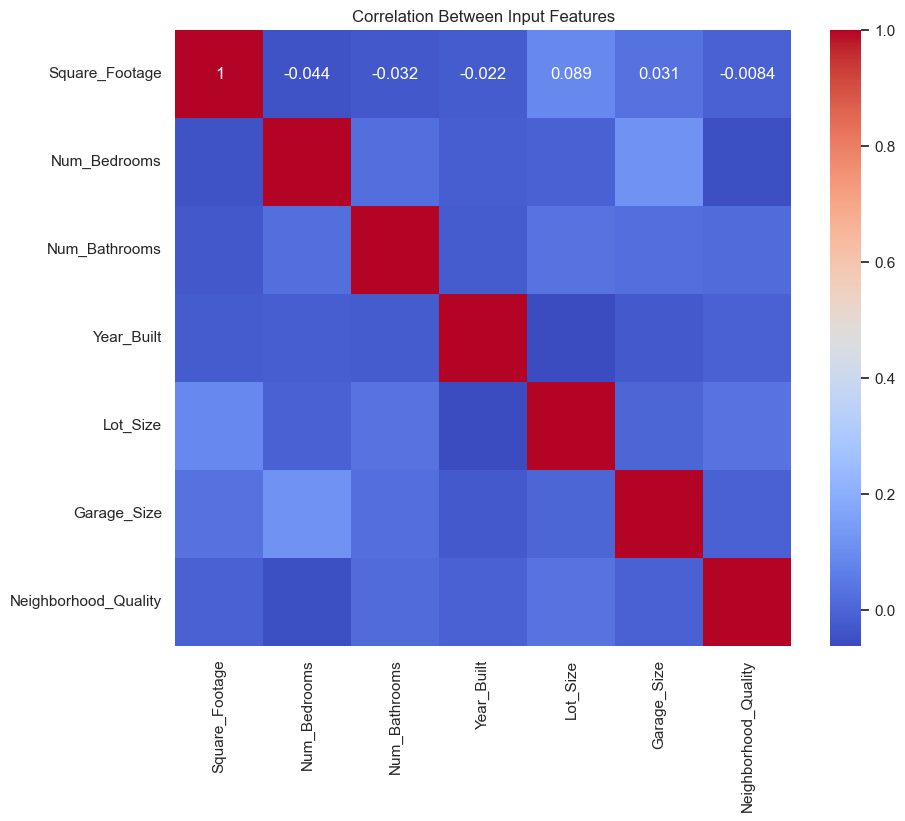

In [38]:
X = df[['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']]

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Between Input Features')
plt.show()

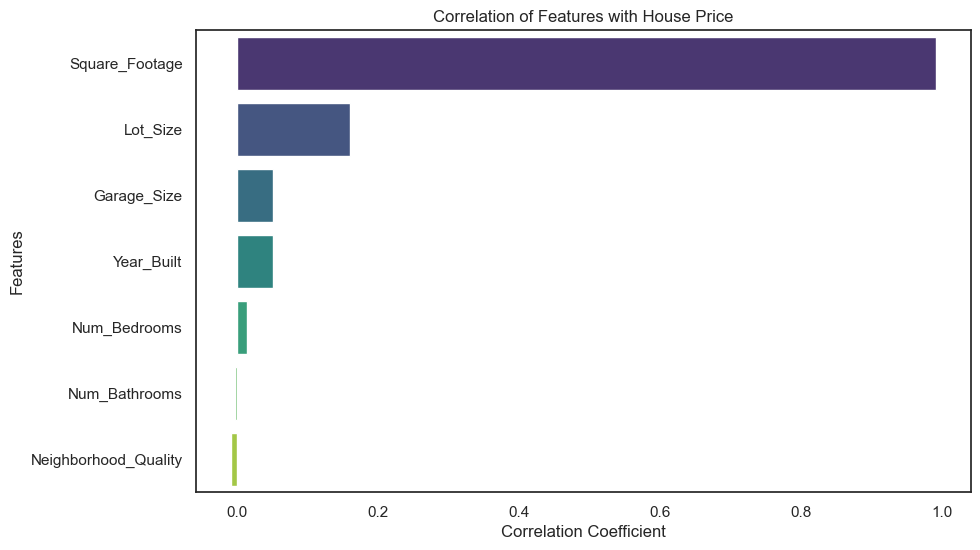

In [39]:
X = df[['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']]
y = df['House_Price']
correlations = X.corrwith(y).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')
plt.title('Correlation of Features with House Price')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

<Axes: xlabel='Square_Footage', ylabel='House_Price'>

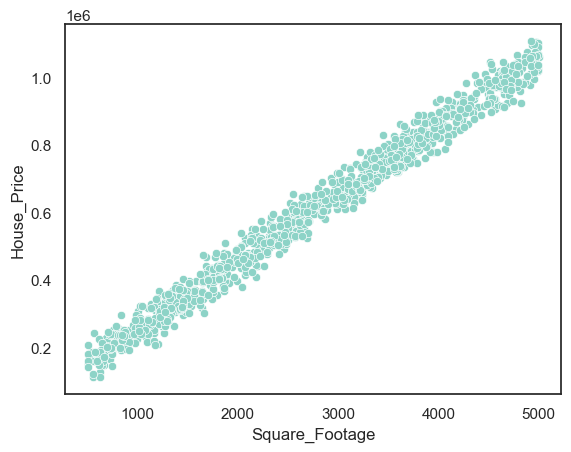

In [40]:
sns.scatterplot(df, x='Square_Footage' , y='House_Price')

<Axes: xlabel='Lot_Size', ylabel='House_Price'>

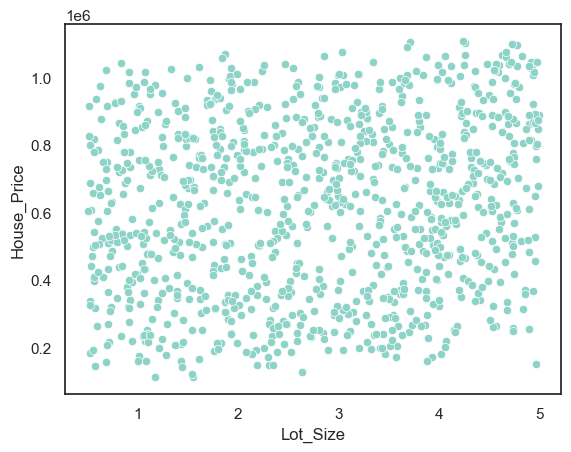

In [41]:
sns.scatterplot(df, x='Lot_Size' , y='House_Price')

<Axes: xlabel='Square_Footage', ylabel='House_Price'>

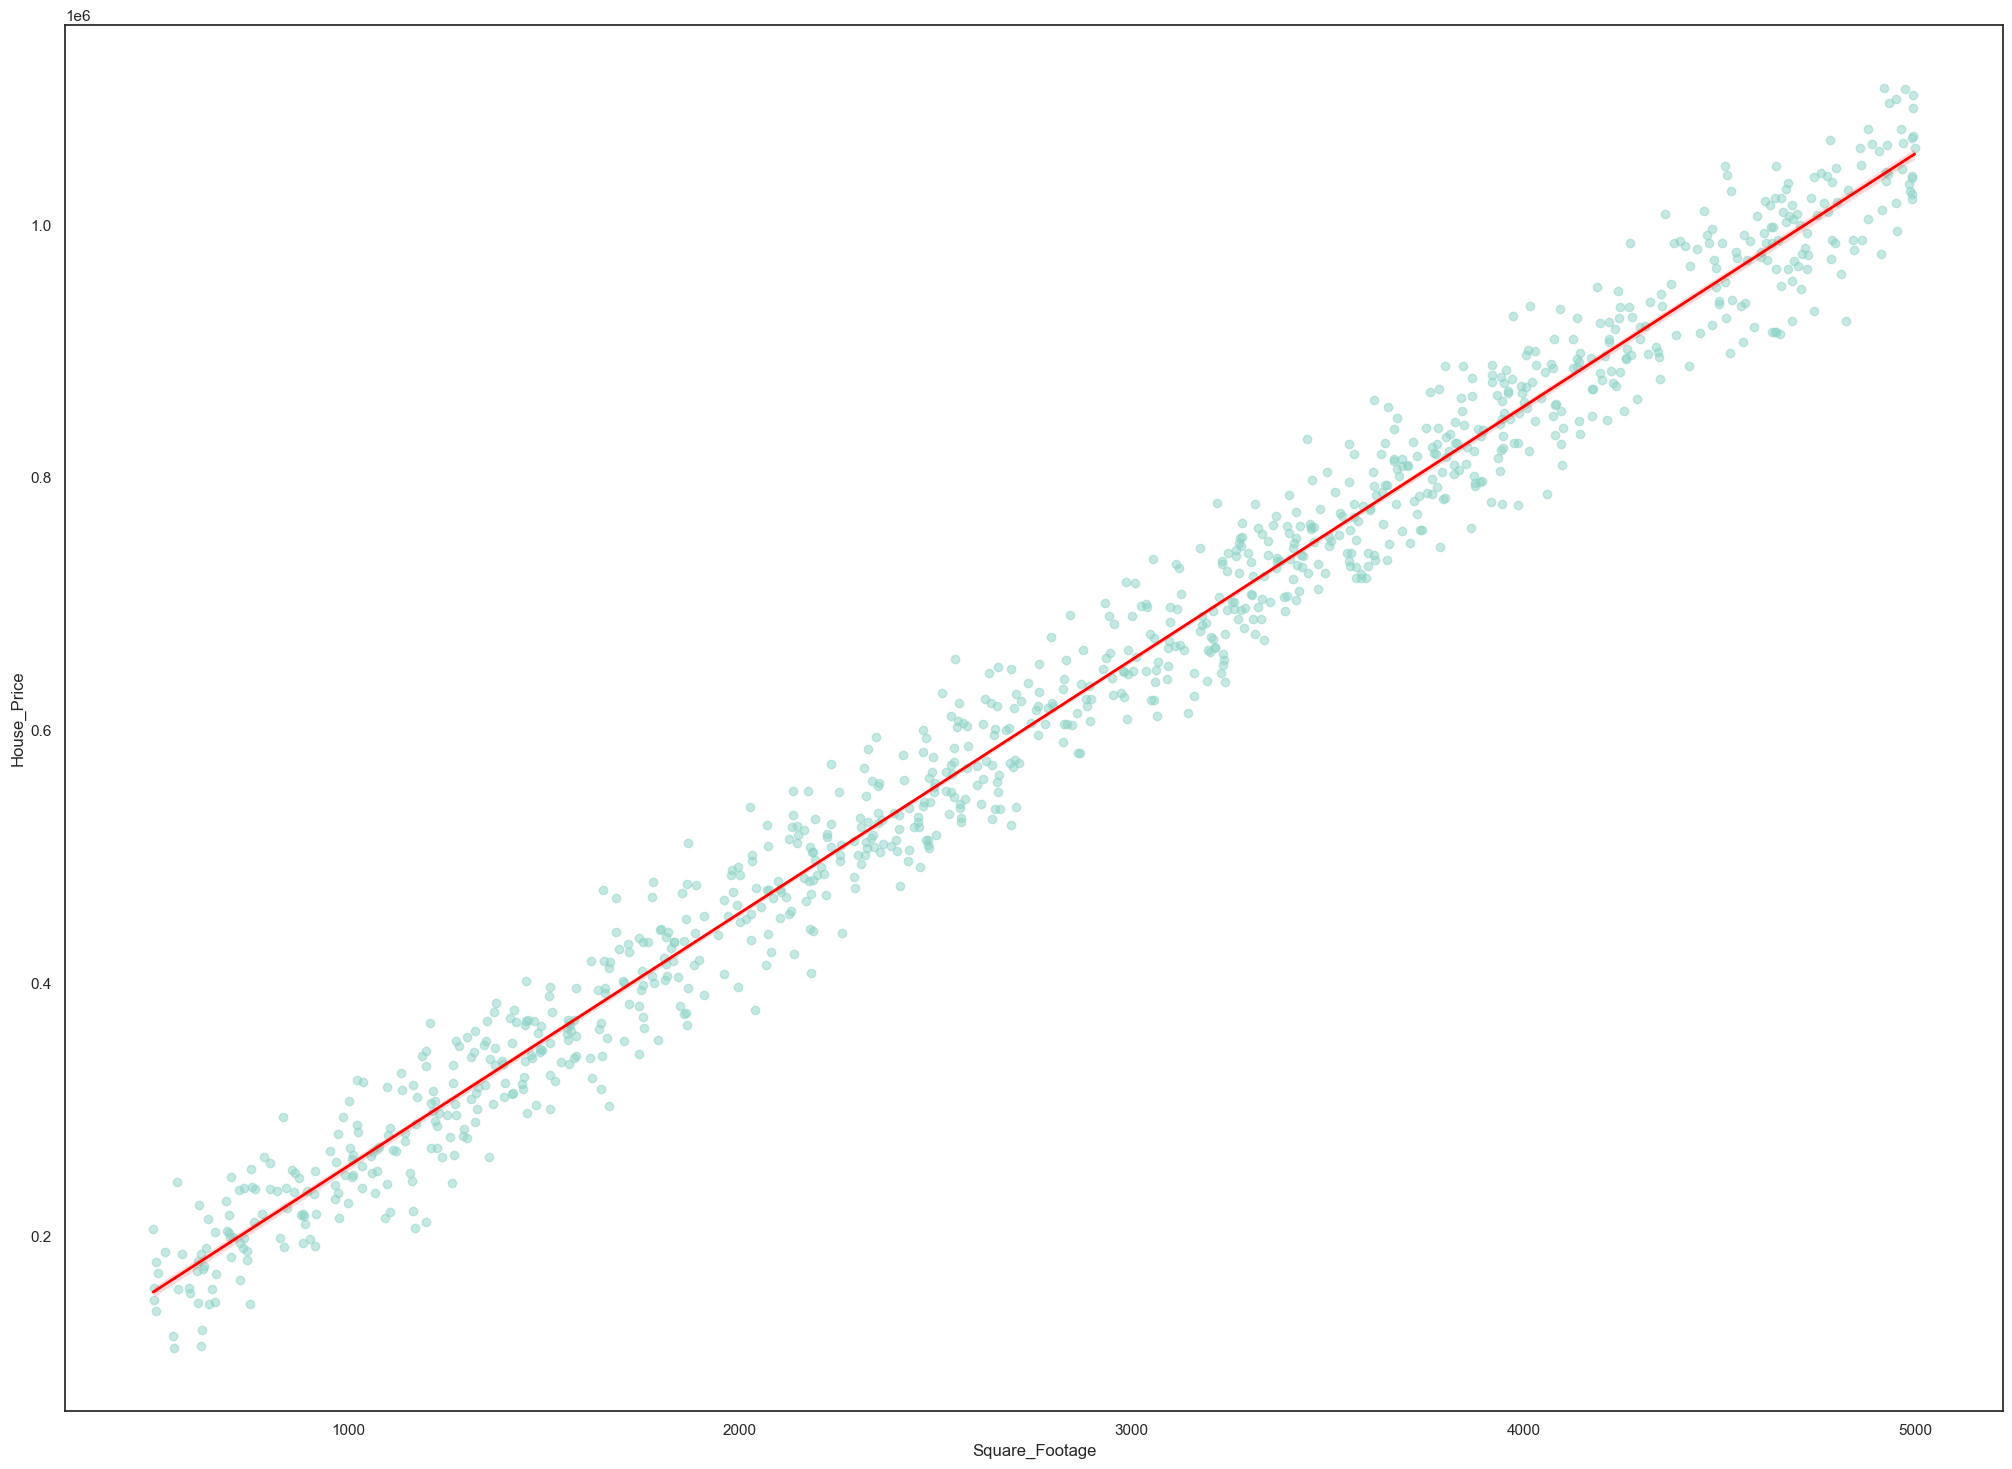

In [42]:
plt.figure(figsize=(25,18))
sns.regplot(x='Square_Footage', y='House_Price', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'linewidth':2})

In [43]:
df.drop(columns=['Num_Bedrooms' , 'Num_Bathrooms', 'Neighborhood_Quality'],inplace=True)

In [44]:
df

,Square_Footage,Year_Built,Lot_Size,Garage_Size,House_Price
0,1360,1981,0.599637,0,2.623829e+05
1,4272,2016,4.753014,1,9.852609e+05
2,3592,2016,3.634823,0,7.779774e+05
3,966,1977,2.730667,1,2.296989e+05
4,4926,1993,4.699073,0,1.041741e+06
...,...,...,...,...,...
995,3261,1978,2.165110,2,7.014940e+05
996,3179,1999,2.977123,1,6.837232e+05
997,2606,1962,4.055067,0,5.720240e+05
998,4723,1950,1.930921,0,9.648653e+05


In [45]:
x=df.drop(columns=['House_Price'])
y=df[['House_Price']]

In [46]:
x

,Square_Footage,Year_Built,Lot_Size,Garage_Size
0,1360,1981,0.599637,0
1,4272,2016,4.753014,1
2,3592,2016,3.634823,0
3,966,1977,2.730667,1
4,4926,1993,4.699073,0
...,...,...,...,...
995,3261,1978,2.165110,2
996,3179,1999,2.977123,1
997,2606,1962,4.055067,0
998,4723,1950,1.930921,0


In [47]:
y

,House_Price
0,2.623829e+05
1,9.852609e+05
2,7.779774e+05
3,2.296989e+05
4,1.041741e+06
...,...
995,7.014940e+05
996,6.837232e+05
997,5.720240e+05
998,9.648653e+05


In [48]:
scaler=  MinMaxScaler()
x=scaler.fit_transform(x)
y=scaler.fit_transform(y)

In [49]:
x

array([[0.19061388, 0.43055556, 0.02087292, 0.        ],
       [0.83830071, 0.91666667, 0.94729512, 0.5       ],
       [0.68705516, 0.91666667, 0.69787952, 0.        ],
       ...,
       [0.46774911, 0.16666667, 0.79161611, 0.        ],
       [0.9386121 , 0.        , 0.31781967, 0.        ],
       [0.6149911 , 0.45833333, 0.58054653, 1.        ]])

In [50]:
y

array([[0.1512688 ],
       [0.87660571],
       [0.66861716],
       [0.11847369],
       [0.93327783],
       [0.7707831 ],
       [0.70519162],
       [0.59379925],
       [0.06245992],
       [0.39388493],
       [0.22446669],
       [0.52525115],
       [0.59151219],
       [0.33021888],
       [0.72956582],
       [0.91065294],
       [0.62634729],
       [0.12305194],
       [0.28558765],
       [0.56313423],
       [0.47607361],
       [0.63068519],
       [0.25941967],
       [0.42062326],
       [0.11628265],
       [0.54237796],
       [0.63620051],
       [0.40290094],
       [0.32182203],
       [0.32363618],
       [0.70043383],
       [0.77481889],
       [0.80356529],
       [0.1702634 ],
       [0.59631799],
       [0.54720865],
       [0.20734232],
       [0.47244354],
       [0.43180461],
       [0.07716616],
       [0.45547998],
       [0.58794083],
       [0.55699484],
       [0.26566177],
       [0.37502544],
       [0.62617435],
       [0.18529229],
       [0.937

In [51]:
X_train , X_test, Y_train , Y_test= train_test_split(x,y,test_size=0.1,shuffle=True,random_state=53)

In [52]:
X_train.shape

(900, 4)

In [53]:
X_test.shape

(100, 4)

In [54]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [55]:
model.score(X_train, Y_train)

0.9945590584451782

In [56]:
Y_pred = model.predict(X_test)

In [57]:
print(mean_squared_error(Y_test , Y_pred))

0.0003414257554899826


In [58]:
print (r2_score (Y_test , Y_pred))

0.9941706916926478
